# Compare with Survey Tree

This document is responsible for drawing the tree based on the summary of the review.

In [30]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def assign_x_positions_with_alternation(intervals):
    """
    Assign x coordinates.
    Arrange nodes alternately to the left and right sides of the trunk.
    This is designed for the version that do not show derivation relationships.
    """
    intervals = sorted(intervals, key=lambda x: x[1])  # Sort by end year
    x_positions = {}  # Record the x coordinate of the keyword
    used_positions = []  # Store the interval assigned to each horizontal axis

    for keyword, start, end in intervals:
        assigned = False
        # Traverse the currently used x coordinates to check whether they can be placed
        for i, pos in enumerate(used_positions):
            if pos[-1] < start:  # No overlap
                used_positions[i].append(end)
                x_positions[keyword] = (
                    (-1 if i % 2 == 0 else 1) * (i // 2 + 1) * 2
                )  # Alternate left and right distribution
                assigned = True
                break
        # If no position is available, assign a new x coordinate
        if not assigned:
            x_positions[keyword] = (
                (-1 if len(used_positions) % 2 == 0 else 1)
                * (len(used_positions) // 2 + 1)
                * 2
            )
            used_positions.append([end])
    return x_positions


def assign_x_positions(keyword_lifetime: dict, derivations: dict) -> dict:
    """
    Assign x coordinates.
    This is a layout function designed for a derivative version.
    """
    # Keyword -> New derived keyword
    keyword_child = {k: [] for k in keyword_lifetime.keys()}
    root_k = []
    for keyword in keyword_lifetime.keys():
        find = False
        for source_keyword in derivations[keyword]:
            if source_keyword not in keyword_lifetime.keys():
                continue
            if keyword_lifetime[source_keyword][0] >= keyword_lifetime[keyword][0]:
                continue
            keyword_child[source_keyword].append(keyword)
            find = True
            break
        if not find:
            root_k.append(keyword)

    # Sort the child array by appearance time from latest to earliest and
    # end time from earliest to latest
    func_life = lambda x: (-int(keyword_lifetime[x][0]), int(keyword_lifetime[x][1]))
    for k, v in keyword_child.items():
        keyword_child[k] = sorted(v, key=func_life)
    root_k = sorted(root_k, key=func_life)

    # First roughly sort to ensure the basic order
    x_rough = {}

    def dfs(fa: str, bias: float) -> None:
        x_fa = x_rough[fa]
        new_bias = bias / (len(keyword_child[fa]) + 3.0)
        for i, c in enumerate(keyword_child[fa]):
            x_rough[c] = (2 if (i % 2) == 0 else -2) * (i // 2 + 0.5) * new_bias + x_fa
            dfs(c, new_bias)

    for i, c in enumerate(root_k):
        x_rough[c] = (1 if (i % 2) == 0 else -1) * (i // 2 + 0.5)
        dfs(c, 0.5)

    # Re-arrange
    sort_keywords = sorted(x_rough.keys(), key=lambda x: x_rough[x])
    left_count = len([v for v in x_rough.values() if v < 0])
    x_positions = {
        k: i - left_count + (1 if i >= left_count else 0)
        for i, k in enumerate(sort_keywords)
    }
    return x_positions


def draw_concept_evolution_tree(
    top_keywords,
    topic_name,
    topic_i,
    topic_id,
    show_derivations=True,
    derivations=None,
    vertical=False,
    save_name=None,
):
    # Data preprocessing
    years = sorted(top_keywords["time_window"].unique())
    keyword_lifetime = {}
    for _, row in top_keywords.iterrows():
        if row["keyword"] not in keyword_lifetime:
            keyword_lifetime[row["keyword"]] = [row["time_window"], row["time_window"]]
        else:
            keyword_lifetime[row["keyword"]][1] = row["time_window"]

    # save keyword_lifetime
    if save_name is not None:
        table = {
            "keyword": [k for k in keyword_lifetime.keys()],
            "start_year": [v[0] for v in keyword_lifetime.values()],
            "end_year": [v[1] for v in keyword_lifetime.values()],
        }
        df = pd.DataFrame.from_dict(table)
        df.to_csv(
            f'./tree_csv_{save_name}/{topic_i}_{topic_name.strip().replace(" ", "_")}.csv'
        )
        with open(
            f'./paper_id_{save_name}/{topic_i}_{topic_name.strip().replace(" ", "_")}.csv',
            mode="w",
            encoding="utf-8",
        ) as f:
            json.dump(topic_id, f)

    if not show_derivations:
        # Assign x coordinates, making sure to alternate left and right
        intervals = [(k, v[0], v[1]) for k, v in keyword_lifetime.items()]
        x_positions = assign_x_positions_with_alternation(intervals)
    else:
        x_positions = assign_x_positions(keyword_lifetime, derivations)

    # Constructing nodes and edges
    keyword_positions = []
    trunk_positions = []  # Store trunk nodes separately
    edges = []
    keyword_last_position = {}
    trunk_x = 0
    for year_idx, year in enumerate(years):
        # Trunk Node
        trunk_positions.append((trunk_x, year_idx))
        current_keywords = top_keywords[top_keywords["time_window"] == year]
        keyword_new_position = {}
        for _, row in current_keywords.iterrows():
            keyword = row["keyword"]
            count = row["count"]
            keyword_x = x_positions[keyword]  # Get the x coordinate of the keyword
            keyword_y = year_idx
            keyword_positions.append((keyword_x, keyword_y, keyword))
            if keyword not in keyword_last_position:
                find_derivations = False
                if show_derivations:  # Derived Relationship Connection
                    for keyword_from in derivations[keyword]:
                        if keyword_from in keyword_last_position:
                            start_x, start_y = keyword_last_position[keyword_from]
                            find_derivations = True
                            break
                if (
                    not find_derivations
                ):  # No derivative relationship, from the main trunk
                    start_x, start_y = trunk_x, year_idx - 1
            else:
                start_x, start_y = keyword_last_position[keyword]
            edges.append((start_x, start_y, keyword_x, keyword_y, count))
            keyword_new_position[keyword] = (keyword_x, keyword_y)
        # Delay the writing of keyword_last_position to avoid interfering with
        # derived relationship connections
        keyword_last_position.update(keyword_new_position)
        
    # pic_width = max(len(keyword_last_position) // 4 + 3, 15)

    # Drawing
    if vertical:
        plt.figure(figsize=(15, 25))
        counts = [edge[4] for edge in edges]
        bias = 1
        norm = LogNorm(vmin=1, vmax=max(counts) + bias + 2)
        cmap = plt.cm.Greens

        # Drawing the tree trunk
        height = [-2, len(years) + 2.5]
        for x, y in trunk_positions:
            plt.plot([x, x], height, color="#654321", linewidth=5, zorder=0)

        # Draw the tree trunk labels
        plt.text(
            trunk_x - 1,
            -1,
            topic_name,
            fontsize=24,
            ha="center",
            va="bottom",
            rotation="vertical",
            color="#654321",
            zorder=4,
            fontweight="bold",
        )

        # Draw Edges
        for start_x, start_y, end_x, end_y, count in edges:
            plt.plot(
                [start_x, end_x],
                [start_y, end_y],
                color=cmap(norm(count + bias)),
                linewidth=12 * norm(count + bias),
                alpha=0.9,
                zorder=1,
            )

        # Draw keyword nodes
        for x, y, keyword in keyword_positions:
            plt.scatter(x, y, color="skyblue", s=60, zorder=2)
            if y == keyword_last_position[keyword][1]:
                plt.text(
                    x,
                    y,
                    keyword,
                    fontsize=22,
                    ha="center",
                    va="bottom",
                    rotation=90,
                    zorder=3,
                    # fontweight="bold",
                )

        # Setting the Axis
        plt.title(
            f'Concept Evolution Tree of the Topic "{topic_name.strip()}"', fontsize=24
        )
        plt.xlabel("Concepts Derived", fontsize=24)
        plt.ylabel("Years", fontsize=24)
        plt.xticks([])  # Hide x-axis scale
        plt.yticks(
            range(len(years)),
            [f"[{int(y) - (int(years[1]) - int(years[0]))}, {y})" for y in years],
            fontsize=24,
        )
        plt.ylim(height[0], height[1])
        plt.tight_layout()
    else:
        plt.figure(figsize=(25, 15))
        counts = [edge[4] for edge in edges]
        bias = 1
        norm = LogNorm(vmin=1, vmax=max(counts) + bias + 2)
        cmap = plt.cm.Greens

        # Drawing the tree trunk
        height = [-2, len(years) + 2.5]
        for x, y in trunk_positions:
            plt.plot(height, [x, x], color="#654321", linewidth=5, zorder=0)

        # Draw the tree trunk labels
        plt.text(
            -1,
            trunk_x - 1,
            topic_name,
            fontsize=24,
            ha="left",
            va="center",
            color="#654321",
            zorder=4,
            fontweight="bold",
        )

        # Draw Edges
        for start_x, start_y, end_x, end_y, count in edges:
            plt.plot(
                [start_y, end_y],
                [start_x, end_x],
                color=cmap(norm(count + bias)),
                linewidth=12 * norm(count + bias),
                alpha=0.9,
                zorder=1,
            )

        # Draw keyword nodes
        for x, y, keyword in keyword_positions:
            plt.scatter(y, x, color="skyblue", s=60, zorder=2)
            if y == keyword_last_position[keyword][1]:
                plt.text(
                    y + 0.05,
                    x,
                    keyword,
                    fontsize=22,
                    ha="left",
                    va="top",
                    rotation=-12,
                    zorder=3,
                )

        # Setting the Axis
        plt.title(
            f'Survey Tree of the Topic "{topic_name.strip()}"', fontsize=24
        )
        plt.xlabel("Years", fontsize=24)
        plt.ylabel("Concepts Derived", fontsize=24)
        plt.xticks(
            range(len(years)),
            [f"[{int(y) - (int(years[1]) - int(years[0]))}, {y})" for y in years],
            fontsize=24,
            rotation=-12,
            ha="left",
        )
        plt.yticks([])  # Hide y-axis scale
        plt.xlim(height[0], height[1])
        plt.tight_layout()

    if save_name is not None:
        plt.savefig(
            f'./tree_fig_{save_name}/{topic_i}_{topic_name.strip().replace(" ", "_")}.pdf'
        )
    else:
        plt.savefig(f'./pic_for_paper/4.2 - Survey Tree of the Topic {topic_name.strip()}.pdf')

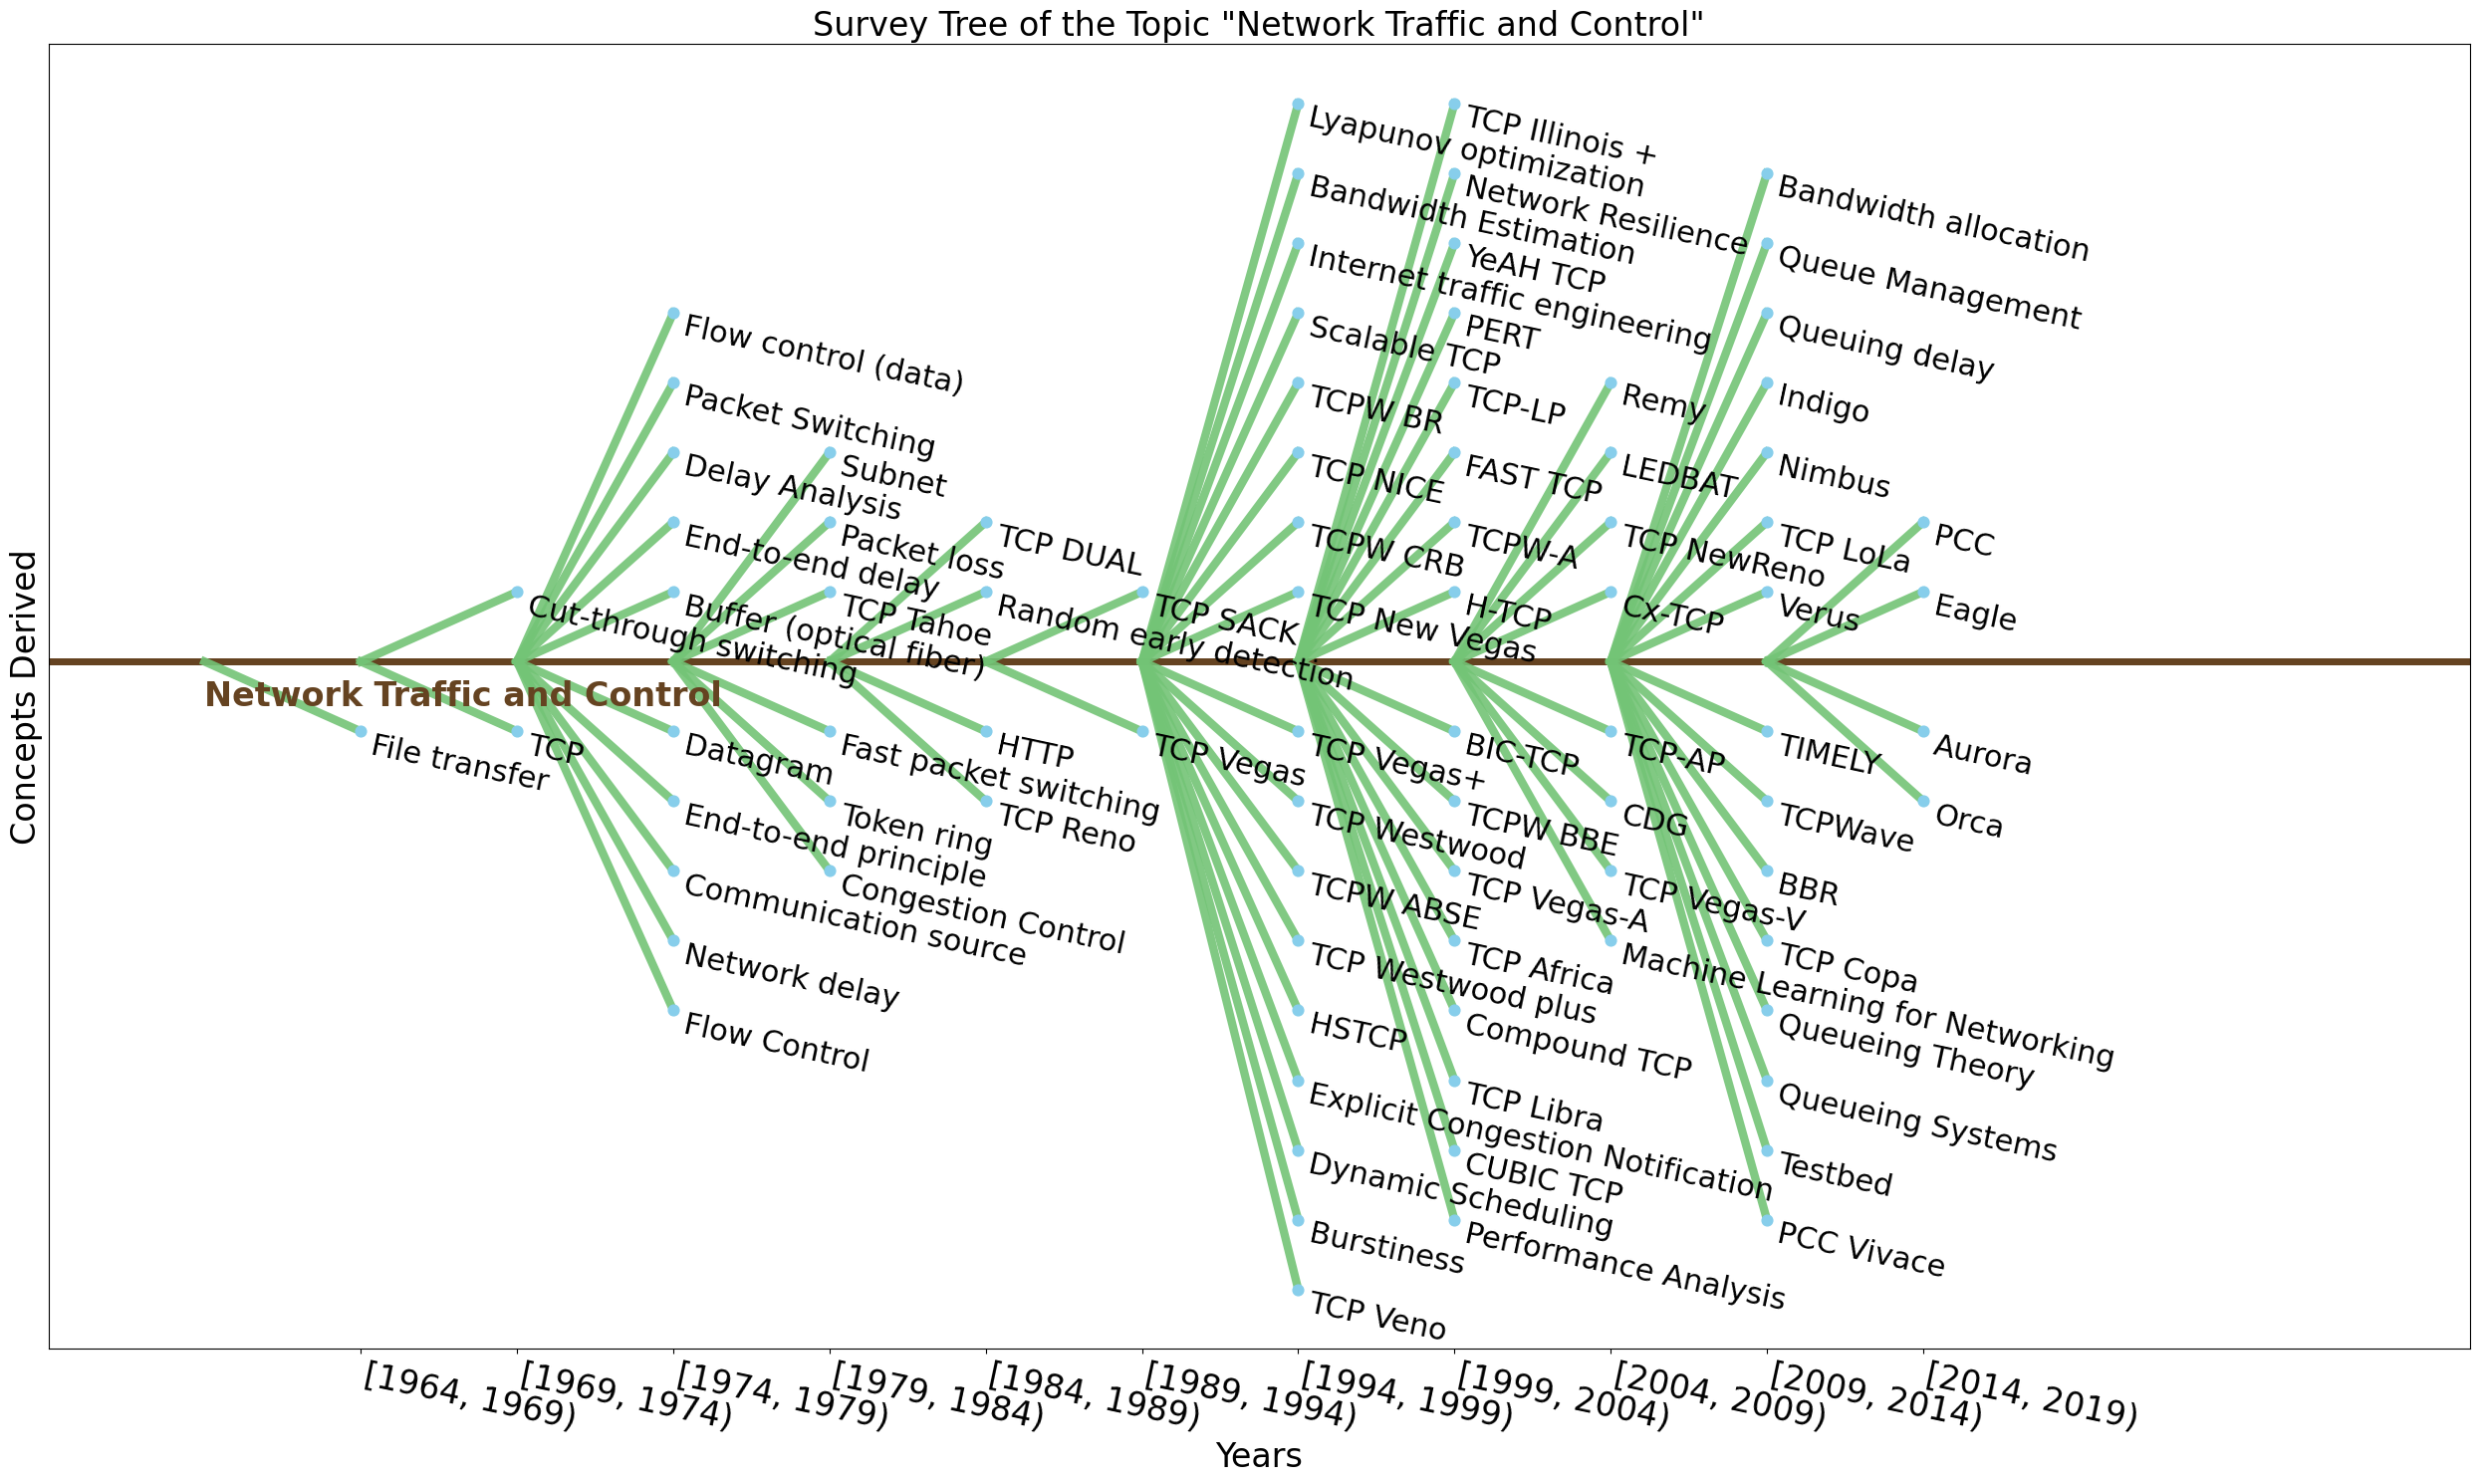

In [31]:
paper_concept = [
    {"time_window": 1969, "keyword": "File transfer", "count": 1},
    {"time_window": 1974, "keyword": "TCP", "count": 1},
    {"time_window": 1974, "keyword": "Cut-through switching", "count": 1},
    {"time_window": 1979, "keyword": "Datagram", "count": 1},
    {"time_window": 1979, "keyword": "Buffer (optical fiber)", "count": 1},
    {"time_window": 1979, "keyword": "End-to-end principle", "count": 1},
    {"time_window": 1979, "keyword": "End-to-end delay", "count": 1},
    {"time_window": 1979, "keyword": "Communication source", "count": 1},
    {"time_window": 1979, "keyword": "Delay Analysis", "count": 1},
    {"time_window": 1979, "keyword": "Network delay", "count": 1},
    {"time_window": 1979, "keyword": "Packet Switching", "count": 1},
    {"time_window": 1979, "keyword": "Flow Control", "count": 1},
    {"time_window": 1979, "keyword": "Flow control (data)", "count": 1},
    {"time_window": 1984, "keyword": "Fast packet switching", "count": 1},
    {"time_window": 1984, "keyword": "TCP Tahoe", "count": 1},
    {"time_window": 1984, "keyword": "Token ring", "count": 1},
    {"time_window": 1984, "keyword": "Packet loss", "count": 1},
    {"time_window": 1984, "keyword": "Congestion Control", "count": 1},
    {"time_window": 1984, "keyword": "Subnet", "count": 1},
    {"time_window": 1989, "keyword": "HTTP", "count": 1},
    {"time_window": 1989, "keyword": "Random early detection", "count": 1},
    {"time_window": 1989, "keyword": "TCP Reno", "count": 1},
    {"time_window": 1989, "keyword": "TCP DUAL", "count": 1},
    {"time_window": 1994, "keyword": "TCP Vegas", "count": 1},
    {"time_window": 1994, "keyword": "TCP SACK", "count": 1},
    {"time_window": 1999, "keyword": "TCP Vegas+", "count": 1},
    {"time_window": 1999, "keyword": "TCP New Vegas", "count": 1},
    {"time_window": 1999, "keyword": "TCP Westwood", "count": 1},
    {"time_window": 1999, "keyword": "TCPW CRB", "count": 1},
    {"time_window": 1999, "keyword": "TCPW ABSE", "count": 1},
    {"time_window": 1999, "keyword": "TCP NICE", "count": 1},
    {"time_window": 1999, "keyword": "TCP Westwood plus", "count": 1},
    {"time_window": 1999, "keyword": "TCPW BR", "count": 1},
    {"time_window": 1999, "keyword": "HSTCP", "count": 1},
    {"time_window": 1999, "keyword": "Scalable TCP", "count": 1},
    {"time_window": 1999, "keyword": "Explicit Congestion Notification", "count": 1},
    {"time_window": 1999, "keyword": "Internet traffic engineering", "count": 1},
    {"time_window": 1999, "keyword": "Dynamic Scheduling", "count": 1},
    {"time_window": 1999, "keyword": "Bandwidth Estimation", "count": 1},
    {"time_window": 1999, "keyword": "Burstiness", "count": 1},
    {"time_window": 1999, "keyword": "Lyapunov optimization", "count": 1},
    {"time_window": 1999, "keyword": "TCP Veno", "count": 1},
    {"time_window": 2004, "keyword": "BIC-TCP", "count": 1},
    {"time_window": 2004, "keyword": "H-TCP", "count": 1},
    {"time_window": 2004, "keyword": "TCPW BBE", "count": 1},
    {"time_window": 2004, "keyword": "TCPW-A", "count": 1},
    {"time_window": 2004, "keyword": "TCP Vegas-A", "count": 1},
    {"time_window": 2004, "keyword": "FAST TCP", "count": 1},
    {"time_window": 2004, "keyword": "TCP Africa", "count": 1},
    {"time_window": 2004, "keyword": "TCP-LP", "count": 1},
    {"time_window": 2004, "keyword": "Compound TCP", "count": 1},
    {"time_window": 2004, "keyword": "PERT", "count": 1},
    {"time_window": 2004, "keyword": "TCP Libra", "count": 1},
    {"time_window": 2004, "keyword": "YeAH TCP", "count": 1},
    {"time_window": 2004, "keyword": "CUBIC TCP", "count": 1},
    {"time_window": 2004, "keyword": "Network Resilience", "count": 1},
    {"time_window": 2004, "keyword": "Performance Analysis", "count": 1},
    {"time_window": 2004, "keyword": "TCP Illinois +", "count": 1},
    {"time_window": 2009, "keyword": "TCP-AP", "count": 1},
    {"time_window": 2009, "keyword": "Cx-TCP", "count": 1},
    {"time_window": 2009, "keyword": "CDG", "count": 1},
    {"time_window": 2009, "keyword": "TCP NewReno", "count": 1},
    {"time_window": 2009, "keyword": "TCP Vegas-V", "count": 1},
    {"time_window": 2009, "keyword": "LEDBAT", "count": 1},
    {"time_window": 2009, "keyword": "Machine Learning for Networking", "count": 1},
    {"time_window": 2009, "keyword": "Remy", "count": 1},
    {"time_window": 2014, "keyword": "TIMELY", "count": 1},
    {"time_window": 2014, "keyword": "Verus", "count": 1},
    {"time_window": 2014, "keyword": "TCPWave", "count": 1},
    {"time_window": 2014, "keyword": "TCP LoLa", "count": 1},
    {"time_window": 2014, "keyword": "BBR", "count": 1},
    {"time_window": 2014, "keyword": "Nimbus", "count": 1},
    {"time_window": 2014, "keyword": "TCP Copa", "count": 1},
    {"time_window": 2014, "keyword": "Indigo", "count": 1},
    {"time_window": 2014, "keyword": "Queueing Theory", "count": 1},
    {"time_window": 2014, "keyword": "Queuing delay", "count": 1},
    {"time_window": 2014, "keyword": "Queueing Systems", "count": 1},
    {"time_window": 2014, "keyword": "Queue Management", "count": 1},
    {"time_window": 2014, "keyword": "Testbed", "count": 1},
    {"time_window": 2014, "keyword": "Bandwidth allocation", "count": 1},
    {"time_window": 2014, "keyword": "PCC Vivace", "count": 1},
    {"time_window": 2019, "keyword": "Aurora", "count": 1},
    {"time_window": 2019, "keyword": "Eagle", "count": 1},
    {"time_window": 2019, "keyword": "Orca", "count": 1},
    {"time_window": 2019, "keyword": "PCC", "count": 1},
]
df = pd.DataFrame(paper_concept)
draw_concept_evolution_tree(df, "Network Traffic and Control", None, None, show_derivations=False)